# Using Shading Functions for Single Points

In [1]:
from pathlib import Path
import os
from datetime import datetime

import rasterio as rio
import numpy as np
from affine import Affine
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import insolation.insolf as insol

In [2]:
pckg_pth = Path('../src').resolve()
os.chdir(pckg_pth)

In [3]:
import insolpy

Load some elevation data.

In [4]:
uydem = Path(r'D:\ArcGIS_Projects\Yellowstone\Upper Yellowstone\prms\MT_hydro_SRTM_30m_clipped.tif')

demr = insolpy.Dem.load_raster(uydem)

### 1. Test the shade_at_points() function

This function can be used if all the necessary inputs are put together by the user. This function is the back-bone for the point based doshade function. It requires the elevation array, resolution, transform, desired point coordinates, and also an array of sun vectors for each point coordinate pair.

Here we create some made up sunvectors, the same length as the number of coordinates we will use, 2.

In [5]:
a = [200, 180]
z = [90, 30]
sv = []
for a, z in zip(a, z):
    svec = insol.normalvector(z, a)
    sv.append(svec)
svs = np.array(sv)

We call the function here, inputing an array of x values and y values for 2-coordinate locations (also made up).

The returned array is the shading factor at all point locations (the columns of the array) for the input sun vector.

In [6]:
insolpy.shade_at_points(demr.data, demr.resolution[0], np.array([-1100898, -1090081]), np.array([2499999, 2501555]), demr.transform, svs)

array([0., 1.])

For this function, there is no coordinate reference checking or bounds so if the points supplied are not in the same CRS or outside the bounds of the raster dataset, it will return indexing errors like shown here.

In [7]:
insolpy.shade_at_points(demr.data, demr.resolution[0], np.array([-1500898, -1090081]), np.array([2499999, 2501555]), demr.transform, svs)

IndexError: index -10618 is out of bounds for axis 1 with size 3102

### 2. Using the doshade_points() function

If looking to get shading at points, one should really use the doshade_points() function as it has at least some error handling and does the leg work of creating correct arguments for the shade_at_points() function.

Next we will test some variations that are possible with the doshade_points() function.

In [8]:
# create a time series
dts = pd.date_range('2000-01-01', '2000-12-31 23:00:00', freq='h')

In [9]:
# use the same points as above but format them into a geopandas GeoDataFrame
pnts = [Point(-1500898, 2499999), Point(-1090081, 2501555)]
geom = gpd.GeoDataFrame(geometry=pnts, crs=5071)

Here we can see with the last set of points from above (that produced the indexing error), the doshade_points() function caught that one of the points is outside the bounds of the raster dataset.

In [10]:
insolpy.doshade_points(demr, geom)

ValueError: An input point is not within the bounds of the raster dataset.

Let's fix that and then run the function with the default settings (which calculates the shading factor at a sun position of zenith=45 and azimuth=315). The default setting is a commonly used sun position when producing hillshading visualization layers. The output is an array that contains the shading factor for each input point (columns) and for each sun position or date time (rows). In this case...both points are not shaded with a value of 1.0 being not shaded and 0.0 being shaded.

In [11]:
pnts = [Point(-1100898, 2499999), Point(-1090081, 2501555)]
geom = gpd.GeoDataFrame(geometry=pnts, crs=5071)

In [12]:
insolpy.doshade_points(demr, geom)

array([[1., 1.]])

Now we manipulate the default inputs to get shading at the two point locations for June 1, 2023 at noon. The dttimes argument accepts several different types including a datetime object, a pandas.Timestamp, and a pandas.DatetimeIndex for multiple dates.

In [13]:
insolpy.doshade_points(demr, geom, dttimes=datetime(2023,6,1,12,0,0))

Dates have been provided, using dates over sun position argument.


array([[1., 1.]])

Now, we can input a single pandas Timestamp to show it does the same thing, this time for May 28, 2024 at 9:00 am.

In [14]:
insolpy.doshade_points(demr, geom, dttimes=pd.Timestamp('2024-05-28 09:00:00'))

Dates have been provided, using dates over sun position argument.


array([[1., 1.]])

Above we created a time-series of hourly date times. Let's give it that and we see the result is similar but now has many more rows, one for each of the input timestamps.

In [15]:
insolpy.doshade_points(demr, geom, dttimes=dts)

Dates have been provided, using dates over sun position argument.


array([[0., 0.],
       [0., 0.],
       [0., 0.],
       ...,
       [0., 0.],
       [0., 0.],
       [0., 0.]], shape=(8784, 2))

Finally, we will give the function multiple sun positions using the sunpos argument instead of date times.

In [16]:
insolpy.doshade_points(demr, geom, sunpos=np.array([[40, 180], [58,215], [26, 199]]))

array([[1., 1.],
       [1., 1.],
       [1., 1.]])

### 3. Determining "hillshading" at points

Hillshading produces a correction factor for downward radiation based on the angle of the terrain and the sun. The hillshade_points() function can use an elevation DEM to determine this correction factor.

The function is essentially the same as doshade_points() except in produces a differen correction factor. Thus, the argument options are pretty much identical. Below we'll run the same options we did earlier for doshade_points().

In [17]:
insolpy.hillshade_points(demr, geom)

array([[0.5004719 , 0.52203949]])

In [18]:
insolpy.hillshade_points(demr, geom, dttimes=datetime(2023,6,1,12,0,0))

Dates have been provided, using dates over sun position argument.


array([[0.        , 0.86239733]])

In [19]:
insolpy.hillshade_points(demr, geom, dttimes=pd.Timestamp('2024-05-28 09:00:00'))

Dates have been provided, using dates over sun position argument.


array([[0.        , 0.87824847]])

In [20]:
hs_ts = insolpy.hillshade_points(demr, geom, dttimes=dts)
hs_ts

Dates have been provided, using dates over sun position argument.


array([[0., 0.],
       [0., 0.],
       [0., 0.],
       ...,
       [0., 0.],
       [0., 0.],
       [0., 0.]], shape=(8784, 2))

We can also veiw the time-series of correction factors by plotting them.

In [21]:
y=hs_ts[:,0]
y1=hs_ts[:,1]

Notice that one of the chosen points is at a location that appears to be self shaded at this time of year.

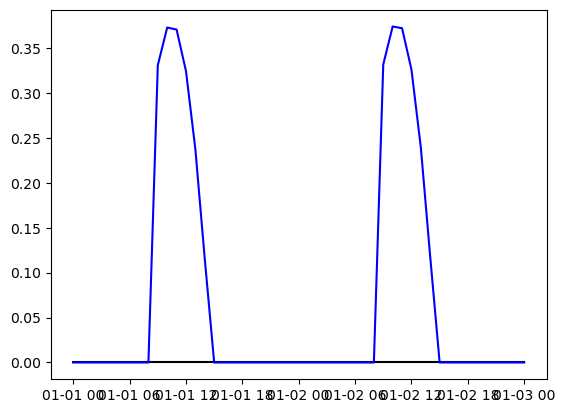

In [22]:
import matplotlib.pyplot as plt
ax = plt.axes()
ax.plot(dts[:49], y[:49], 'k-')
ax.plot(dts[:49], y1[:49], 'b-')

If we choose a different time of the year (here instead of January, we select some dates in June), we can see that the self-shaded point does receive incoming solar radiation when the sun is higher in the sky, but is oriented that most sunlight reaches it just before sunset and just after sunrise.

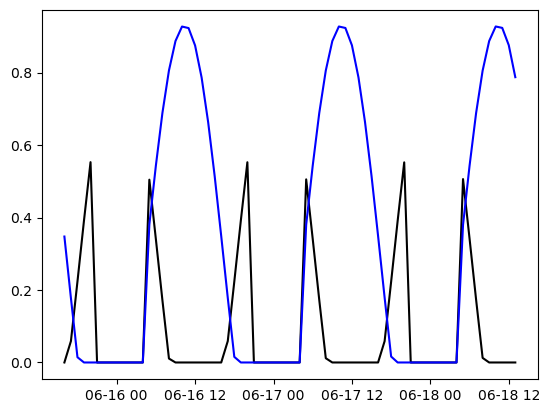

In [24]:
ax = plt.axes()
ax.plot(dts[4000:4070], y[4000:4070], 'k-')
ax.plot(dts[4000:4070], y1[4000:4070], 'b-')

And finally, just like doshade_points() we can instead pass in an array of sun positions as zenith and azimuth angles.

In [23]:
insolpy.hillshade_points(demr, geom, sunpos=np.array([[40, 180], [58,215], [26, 199]]))

array([[0.        , 0.67766567],
       [0.        , 0.28604322],
       [0.        , 0.76728501]])